In [18]:
import pandas as pd

def read_csv(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=";")
    df = df.drop_duplicates()
    df = df.fillna(value=0)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
    df['Date'] = df['Date'].dt.to_period('M')
    return df

filepath = "dataset.csv"
output_file = "cleaned_dataset.csv"

df = read_csv(filepath)
df.to_csv(output_file, index=False)

print(df)

          Date   Service           Departure station     Arrival station  \
0      2018-01  National            BORDEAUX ST JEAN  PARIS MONTPARNASSE   
1      2018-01  National                     LE MANS  PARIS MONTPARNASSE   
2      2018-01  National          PARIS MONTPARNASSE   LA ROCHELLE VILLE   
3      2018-01  National          PARIS MONTPARNASSE              NANTES   
4      2018-01  National                    POITIERS  PARIS MONTPARNASSE   
...        ...       ...                         ...                 ...   
12033      NaT  National  SAINT ETIENNE CHATEAUCREUX          PARIS LYON   
12034      NaT         0          PARIS MONTPARNASSE              NANTES   
12049  2018-03         0                  PERPIGNAN           PARIS LYON   
12056      NaT  National                  NICE VILLE          PARIS LYON   
12060  2022-03  National                  Paris Lyon      MULHOUSE VILLE   

      Average journey time Number of scheduled trains  \
0                    141.0    

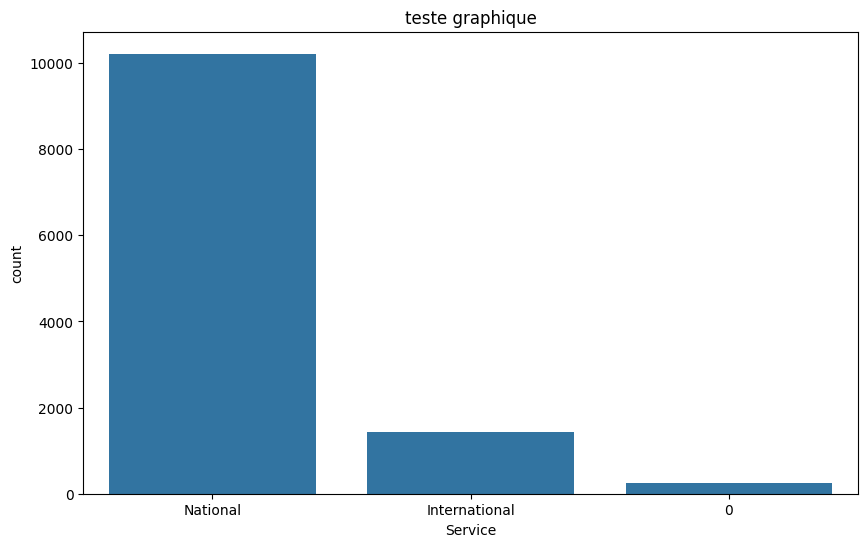

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Service')
plt.title("teste graphique")
plt.show()

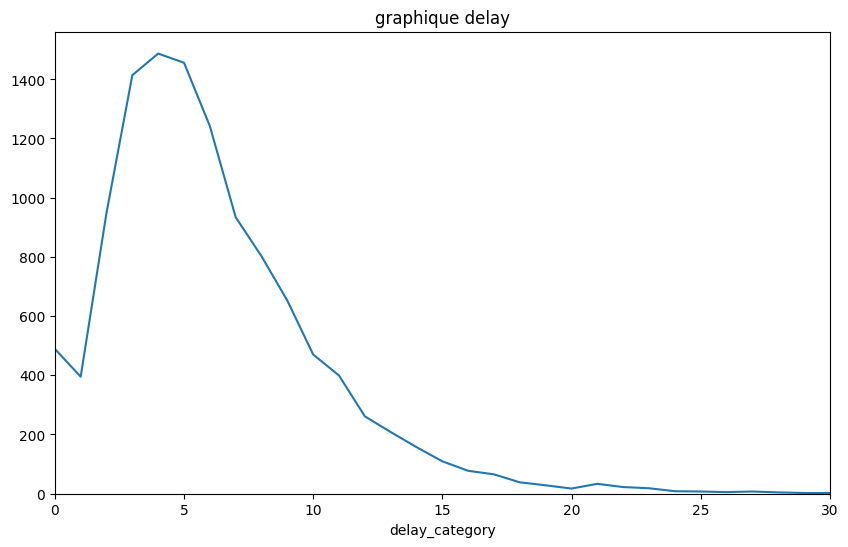

In [ ]:
df['delay_category'] = pd.to_numeric(df['Average delay of all trains at arrival'], errors='coerce').round()
counts = df['delay_category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=counts.index, y=counts.values)
plt.xlim(0, 30)
plt.ylim(0)
plt.title("graphique delay")
plt.show()